# Sandboxed agent: 격리된 작업 공간

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ksmin23/agent-pattern-examples/blob/feat/workflow-planning-colab/patterns/sandboxed_agent/examples/workspace_inspection/notebooks/sandboxed_agent-ko.ipynb)

**대상:** Python 함수와 async/await에 익숙한 Agent 입문자.

**학습 목표:** Manifest → shell capability → SandboxAgent → 실행 및 정리 과정을 Agent 정의와 실행 셀로 직접 구성합니다.

**순서:** 환경 준비 → 입력·Agent 정의 → 실행 → 결과 확인 → 작은 실습.

소스 코드 · 예제 안내 · 환경 설정

### 패턴 구조

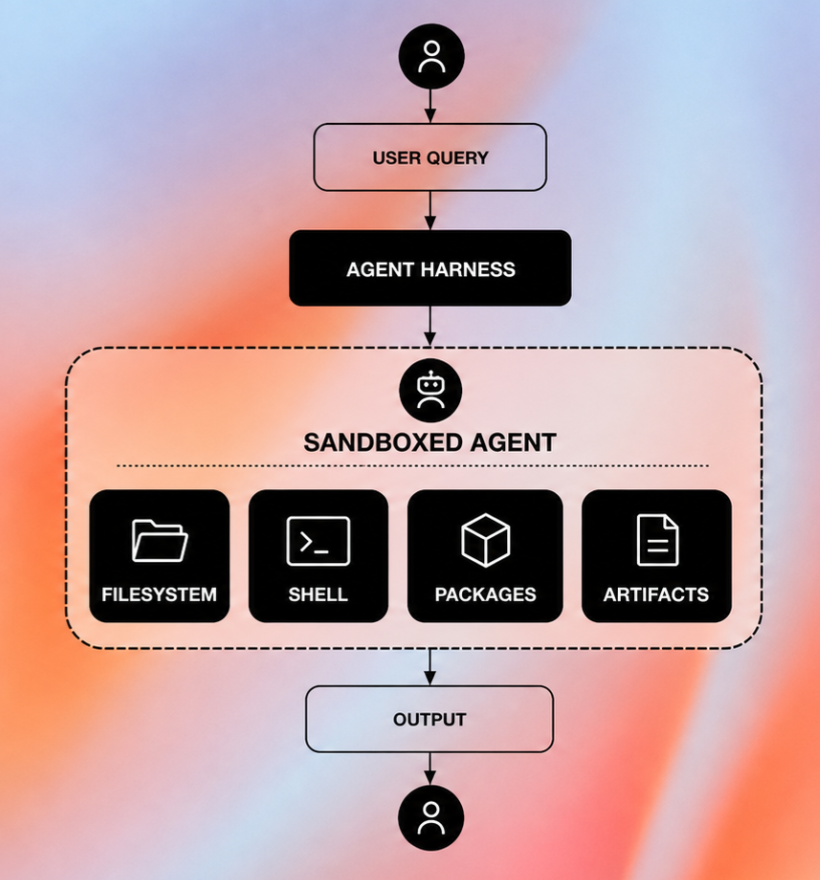

### 그림을 코드로 읽기

| 그림의 구성 요소 | 코드 구현 | 역할 |
| --- | --- | --- |
| User Query | `question` | 작업 공간을 조사하라는 요청 |
| Agent Harness | `Runner.run()`과 `SandboxRunConfig` | Agent 실행과 sandbox session을 연결 |
| Sandboxed Agent | `SandboxAgent` | 격리된 환경의 도구를 사용하는 Agent |
| Filesystem | `Manifest`와 `File` | sandbox에 제공할 초기 파일 정의 |
| Shell | `WorkspaceShellCapability` | sandbox 내부 명령 실행 |
| Packages | Docker 또는 Modal sandbox image | 격리된 실행 환경과 설치 패키지 제공 |
| Output | `sandbox_result.final_output` | 파일을 조사한 뒤 생성한 응답 |

#### 실행 흐름

1. `Manifest`에 Agent가 조사할 파일을 정의합니다.
2. `WorkspaceShellCapability`가 shell 도구를 sandbox session에 연결합니다.
3. `sandbox_session()`이 환경에 맞는 백엔드로 격리된 session을 생성하고 시작합니다.
4. `Runner.run()`이 session 안에서 `SandboxAgent`를 실행합니다.
5. 실행이 끝나면 session을 정리하고 Docker를 사용했다면 연결도 닫습니다.

#### 그림과 이 예제의 차이

그림은 filesystem, shell, packages, artifacts를 sandbox의 일반 기능으로 보여줍니다. 이 Notebook은 그중 초기 파일과 shell 실행을 직접 구현하며, packages는 선택한 백엔드의 image를 통해 제공됩니다. 별도의 artifact 생성 흐름은 포함하지 않습니다.

## 1. 환경 준비

### Colab

1. 이 `.ipynb` 파일을 Colab의 **파일 → 노트북 업로드**로 엽니다. 저장소 복제나 Google Drive 마운트는 필요하지 않습니다. CPU 런타임으로 실행할 수 있습니다.
2. 아래 설정 셀이 `openai-agents[modal]==0.22.1`과 `python-dotenv`를 필요한 경우 설치합니다. 이미 다른 SDK 버전을 import했다면 런타임을 다시 시작한 뒤 위에서부터 실행하세요.
3. 실제 API 실행을 원하면 왼쪽 **Secrets(열쇠 아이콘)**에 기존 키를 `OPENAI_API_KEY` 이름으로 등록하고 이 Notebook의 접근 권한을 켭니다. 키를 코드 셀에 붙여넣지 마세요. 로컬 `.env.local`은 Colab에 자동 전달되지 않습니다.

### 로컬 Jupyter

`uv`로 공통 Notebook 환경을 설치한 뒤 해당 커널을 선택하세요. 기존 환경 변수를 우선 사용하며, 현재 위치 또는 상위 디렉터리에 `.env.local`이 있으면 추가 설정을 읽습니다. 오프라인 실습에는 `.env.local`이나 API 키가 필요하지 않습니다.

### 실행 설정

기본 `RUN_API=False`에서는 Secrets 조회와 API 호출 없이 Agent 구성과 오프라인 실습을 실행합니다. API 결과를 보려면 다음 셀에서 `RUN_API=True`로 변경하고 아래 셀을 순서대로 실행하세요. 키는 **환경 변수 → 선택적 `.env.local` → Colab Secrets** 순서로 찾으며 값을 출력하거나 파일에 저장하지 않습니다. 모델 호출 및 웹 검색에는 비용이 발생할 수 있습니다. Notebook에서는 `asyncio.run()` 대신 최상위 `await`를 사용합니다.

후반 독립 실행 예제는 별도의 `run_api=True` 인수로 활성화합니다. 앞부분의 `RUN_API` 변경은 이 인수에 적용되지 않습니다.

### Sandbox 실행 환경

- 로컬은 Docker, Colab은 원격 Modal Sandbox가 기본입니다. `SANDBOX_BACKEND` 환경 변수로 선택할 수 있습니다.
- Colab 실제 실행에는 Modal 계정과 API 토큰이 필요합니다. Modal 계정 설정에서 API 토큰을 발급한 뒤 Colab Secrets에 `MODAL_TOKEN_ID`, `MODAL_TOKEN_SECRET`을 등록하고 Notebook 접근 권한을 허용하세요. `OPENAI_API_KEY`도 필요합니다.
- 토큰은 Colab 런타임에서 인증에만 사용하며 sandbox 파일이나 Manifest에 넣지 않습니다. `RUN_API=False`에서는 토큰 조회와 원격 자원 생성을 생략합니다.
- Modal 사용료가 별도로 발생할 수 있습니다. 세션 종료 시 삭제를 시도하고, 최대 수명은 300초로 설정합니다. 강제 런타임 종료 등으로 정리가 중단되면 Modal 대시보드에서 확인하세요.
- 인증 방식: [Modal 공식 문서](https://modal.com/docs/reference/modal.config). 로컬에서 Modal을 선택하려면 `openai-agents[modal]==0.22.1`을 설치하고 Modal 인증을 준비하세요.


In [ ]:
import os
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

# Install only in Colab. Local environments use requirements-notebooks.txt.
try:
    import google.colab
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    try:
        dependencies_ready = (
            version("openai-agents") == "0.22.1"
            and version("python-dotenv").split(".")[0] == "1"
            and version("modal") == "1.4.3"
        )
    except PackageNotFoundError:
        dependencies_ready = False
    if not dependencies_ready:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--quiet",
            "openai-agents[modal]==0.22.1", "python-dotenv>=1,<2",
        ])

from agents import RunConfig, Runner, set_tracing_disabled
from dotenv import find_dotenv, load_dotenv


def load_environment(*, run_api: bool) -> str:
    """Load optional local settings; request Colab Secrets only for live runs."""
    env_path = find_dotenv(filename=".env.local", usecwd=True)
    if env_path:
        load_dotenv(env_path, override=False)

    if run_api and not os.getenv("OPENAI_API_KEY", "").strip():
        try:
            from google.colab import userdata
        except ImportError:
            raise RuntimeError(
                "Set OPENAI_API_KEY in your environment or .env.local before enabling API calls."
            ) from None

        try:
            key = userdata.get("OPENAI_API_KEY")
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError, userdata.TimeoutException):
            raise RuntimeError(
                "In Colab Secrets, add OPENAI_API_KEY and enable Notebook access, "
                "then rerun this cell."
            ) from None
        if not isinstance(key, str) or not key.strip():
            raise RuntimeError("The OPENAI_API_KEY secret is empty.")
        os.environ["OPENAI_API_KEY"] = key.strip()

    return os.getenv("AGENT_MODEL", "gpt-5.6-luna")


RUN_API = False  # Set True for the walkthrough's API and web search calls.
MODEL = load_environment(run_api=RUN_API)
set_tracing_disabled(True)
print({"environment": "Colab" if IN_COLAB else "local", "model": MODEL, "api_enabled": RUN_API})


## 2. Sandbox API와 모델

로컬 Docker 실행에는 Docker daemon이 필요합니다. Colab은 원격 Modal Sandbox를 사용합니다. `SANDBOX_MODEL`의 기본값은 `gpt-5.6-sol`입니다.


In [ ]:
from agents import ModelSettings
from agents.sandbox import Manifest, SandboxAgent, SandboxRunConfig
from agents.sandbox.config import DEFAULT_PYTHON_SANDBOX_IMAGE
from agents.sandbox.entries import File

SANDBOX_MODEL = os.getenv("SANDBOX_MODEL", "gpt-5.6-sol")

from contextlib import asynccontextmanager


def sandbox_backend() -> str:
    try:
        import google.colab
    except ImportError:
        default = "docker"
    else:
        default = "modal"
    backend = os.getenv("SANDBOX_BACKEND", default)
    if backend not in {"docker", "modal"}:
        raise ValueError("SANDBOX_BACKEND must be docker or modal.")
    return backend


def load_modal_credentials() -> None:
    # Local Modal can use its existing CLI profile. Colab uses Secrets or env vars.
    try:
        from google.colab import userdata
    except ImportError:
        return
    for name in ("MODAL_TOKEN_ID", "MODAL_TOKEN_SECRET"):
        if os.getenv(name, "").strip():
            continue
        try:
            value = userdata.get(name)
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError, userdata.TimeoutException):
            raise RuntimeError(
                f"Add {name} to Colab Secrets and enable Notebook access."
            ) from None
        if not isinstance(value, str) or not value.strip():
            raise RuntimeError(f"Colab Secret {name} is empty.")
        os.environ[name] = value.strip()


@asynccontextmanager
async def sandbox_session(manifest):
    """Use remote Modal in Colab or Docker locally; always attempt cleanup."""
    backend = sandbox_backend()
    docker_api = None
    client = None
    session = None
    try:
        if backend == "modal":
            load_modal_credentials()
            from agents.extensions.sandbox import ModalSandboxClient, ModalSandboxClientOptions
            client = ModalSandboxClient()
            options = ModalSandboxClientOptions(
                app_name=os.getenv("MODAL_APP_NAME", "agent-pattern-examples"),
                timeout=300,
            )
        else:
            from docker import from_env
            from agents.sandbox.sandboxes.docker import DockerSandboxClient, DockerSandboxClientOptions
            docker_api = from_env()
            docker_api.ping()
            client = DockerSandboxClient(docker_api)
            options = DockerSandboxClientOptions(image=DEFAULT_PYTHON_SANDBOX_IMAGE)
        session = await client.create(manifest=manifest, options=options)
        await session.start()
        async with session:
            yield session
    finally:
        try:
            if session is not None:
                await client.delete(session)
        finally:
            if docker_api is not None:
                docker_api.close()

print({"sandbox_backend": sandbox_backend()})


## 3. shell 도구 연결

로컬 소스의 보조 클래스를 그대로 셀에 정의합니다. shell 요청을 현재 sandbox 세션의 exec로 전달합니다.

In [ ]:
from __future__ import annotations

from agents.sandbox import Capability, Manifest
from agents.sandbox.session.base_sandbox_session import BaseSandboxSession
from agents.tool import (
    ShellCallOutcome,
    ShellCommandOutput,
    ShellCommandRequest,
    ShellResult,
    ShellTool,
    Tool,
)


class WorkspaceShellCapability(Capability):
    """Expose one shell tool for inspecting the active sandbox workspace."""

    def __init__(self) -> None:
        super().__init__(type="workspace_shell")
        self._session: BaseSandboxSession | None = None

    def bind(self, session: BaseSandboxSession) -> None:
        self._session = session

    def tools(self) -> list[Tool]:
        return [ShellTool(executor=self._execute_shell)]

    async def instructions(self, manifest: Manifest) -> str | None:
        _ = manifest
        return (
            "Use the `shell` tool to inspect the sandbox workspace before answering. "
            "The workspace root is the current working directory, "
            "so prefer relative paths "
            "with commands like `pwd`, `find .`, and `cat`. "
            "Only cite files you actually read."
        )

    async def _execute_shell(self, request: ShellCommandRequest) -> ShellResult:
        if self._session is None:
            raise RuntimeError("Workspace shell is not bound to a sandbox session.")

        # Zero is intentionally equivalent to no explicit Shell action timeout.
        timeout_ms = request.data.action.timeout_ms
        timeout_s = timeout_ms / 1000 if timeout_ms else None
        outputs: list[ShellCommandOutput] = []

        for command in request.data.action.commands:
            result = await self._session.exec(
                command,
                timeout=timeout_s,
                shell=True,
            )
            outputs.append(
                ShellCommandOutput(
                    command=command,
                    stdout=result.stdout.decode("utf-8", errors="replace"),
                    stderr=result.stderr.decode("utf-8", errors="replace"),
                    outcome=ShellCallOutcome(
                        type="exit",
                        exit_code=result.exit_code,
                    ),
                )
            )

        return ShellResult(output=outputs)

## 4. 작업 파일과 Agent 정의

호스트 폴더 전체를 마운트하지 않고, 아래의 작은 파일 두 개만 준비합니다.

In [ ]:
manifest = Manifest(
    entries={
        "README.md": File(content=b"# Demo Project\nA tiny greeting application.\n"),
        "src/app.py": File(
            content=b'def greet(name):\n    return f"Hello, {name}!"\n'
        ),
    }
)

workspace_agent = SandboxAgent(
    name="Workspace inspector",
    model=SANDBOX_MODEL,
    instructions=(
        "Inspect the files with shell and explain what the project does in two "
        "sentences. Only describe files you actually inspected."
    ),
    default_manifest=manifest,
    capabilities=[WorkspaceShellCapability()],
    model_settings=ModelSettings(tool_choice="required"),
)

question = "Read README.md and src/app.py, then summarize this project."

## 5. Sandbox 준비 → 실행 → 정리 · API 및 Sandbox 호출

`sandbox_session()`은 로컬 Docker 또는 Colab의 Modal 세션을 생성합니다. 성공·실패 후 `finally`에서 삭제를 시도하고 Docker 연결도 닫습니다. Modal의 최대 세션 수명은 300초이며, 삭제 성공을 보장하는 것은 아닙니다.


In [ ]:
sandbox_result = None

if RUN_API:
    async with sandbox_session(manifest) as session:
        sandbox_result = await Runner.run(
            workspace_agent,
            question,
            max_turns=6,
            run_config=RunConfig(sandbox=SandboxRunConfig(session=session)),
        )
        print(sandbox_result.final_output)
else:
    print("Sandbox and API execution skipped; Agent and Manifest definitions are ready.")


## 6. 실제 도구 실행 확인

문맥만으로 답하지 않고 shell 도구를 호출했는지 확인합니다.

In [ ]:
if sandbox_result is not None:
    calls = [
        item
        for item in sandbox_result.new_items
        if item.type == "tool_call_item"
    ]

    assert calls, "No shell tool calls were made."
    assert str(sandbox_result.final_output).strip()

    print({"tool_calls": len(calls)})

## 7. 별도 파일로 구성하기: `main()` 실행 진입점

앞의 단계별 실습을 하나의 Python 모듈로 구성한 추가 예제입니다. 앞에서 만든 Agent나 전역 변수에 의존하지 않으므로, 공통 실습 패키지가 설치되어 있다면 아래 코드 셀부터 실행할 수 있습니다.

원본처럼 `main()`을 진입점으로 두고, **작업 공간 생성 → shell로 파일 확인 → 결과 반환 → 세션 삭제**를 재사용 가능한 함수로 묶습니다. 앞의 실습과 동일한 파일, shell 도구, 모델 기본값과 최대 턴 수를 사용합니다.

| 구성 | 책임 |
| --- | --- |
| `StandaloneWorkspaceShellCapability` | shell 요청을 Sandbox 세션의 명령 실행으로 연결 |
| `build_workspace_agent()` | Manifest와 새 SandboxAgent 구성 |
| `inspect_workspace()` | Docker/Modal 세션 생성·시작, Agent 실행, 결과 확인, 자원 정리 |
| `main()` | 환경 설정, 실행 여부 결정, 입력 전달과 결과 출력 |

실행마다 새로운 세션을 만들며, 생성된 세션은 실행이 실패해도 `finally`에서 삭제를 시도합니다. Docker 연결도 별도의 `finally`에서 닫으므로 세션 생성이나 삭제 과정의 오류에도 연결 정리가 수행됩니다. 컨테이너 삭제가 실패하면 오류가 전달되며, 삭제 완료를 보장하지는 않습니다.

기본값 `run_api=False`에서는 Sandbox와 API를 호출하지 않습니다. 로컬은 Docker 데몬, Colab은 Modal 토큰이 필요합니다. 모델은 환경 변수 또는 선택적 `.env.local`의 `SANDBOX_MODEL`을 사용하며 기본값은 `gpt-5.6-sol`입니다. 일반 `AGENT_MODEL`과 별도로 설정합니다.


In [ ]:
from __future__ import annotations

import asyncio
import os

from agents import ModelSettings, RunConfig, Runner, set_tracing_disabled
from agents.sandbox import Capability, Manifest, SandboxAgent, SandboxRunConfig
from agents.sandbox.config import DEFAULT_PYTHON_SANDBOX_IMAGE
from agents.sandbox.entries import File
from agents.sandbox.session.base_sandbox_session import BaseSandboxSession
from agents.tool import (
    ShellCallOutcome,
    ShellCommandOutput,
    ShellCommandRequest,
    ShellResult,
    ShellTool,
    Tool,
)
from dotenv import find_dotenv, load_dotenv


from contextlib import asynccontextmanager


def sandbox_backend() -> str:
    try:
        import google.colab
    except ImportError:
        default = "docker"
    else:
        default = "modal"
    backend = os.getenv("SANDBOX_BACKEND", default)
    if backend not in {"docker", "modal"}:
        raise ValueError("SANDBOX_BACKEND must be docker or modal.")
    return backend


def load_modal_credentials() -> None:
    # Local Modal can use its existing CLI profile. Colab uses Secrets or env vars.
    try:
        from google.colab import userdata
    except ImportError:
        return
    for name in ("MODAL_TOKEN_ID", "MODAL_TOKEN_SECRET"):
        if os.getenv(name, "").strip():
            continue
        try:
            value = userdata.get(name)
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError, userdata.TimeoutException):
            raise RuntimeError(
                f"Add {name} to Colab Secrets and enable Notebook access."
            ) from None
        if not isinstance(value, str) or not value.strip():
            raise RuntimeError(f"Colab Secret {name} is empty.")
        os.environ[name] = value.strip()


@asynccontextmanager
async def sandbox_session(manifest):
    """Use remote Modal in Colab or Docker locally; always attempt cleanup."""
    backend = sandbox_backend()
    docker_api = None
    client = None
    session = None
    try:
        if backend == "modal":
            load_modal_credentials()
            from agents.extensions.sandbox import ModalSandboxClient, ModalSandboxClientOptions
            client = ModalSandboxClient()
            options = ModalSandboxClientOptions(
                app_name=os.getenv("MODAL_APP_NAME", "agent-pattern-examples"),
                timeout=300,
            )
        else:
            from docker import from_env
            from agents.sandbox.sandboxes.docker import DockerSandboxClient, DockerSandboxClientOptions
            docker_api = from_env()
            docker_api.ping()
            client = DockerSandboxClient(docker_api)
            options = DockerSandboxClientOptions(image=DEFAULT_PYTHON_SANDBOX_IMAGE)
        session = await client.create(manifest=manifest, options=options)
        await session.start()
        async with session:
            yield session
    finally:
        try:
            if session is not None:
                await client.delete(session)
        finally:
            if docker_api is not None:
                docker_api.close()


class StandaloneWorkspaceShellCapability(Capability):
    """Expose one shell tool for inspecting the active sandbox workspace."""

    def __init__(self) -> None:
        super().__init__(type="workspace_shell")
        self._session: BaseSandboxSession | None = None

    def bind(self, session: BaseSandboxSession) -> None:
        self._session = session

    def tools(self) -> list[Tool]:
        return [ShellTool(executor=self._execute_shell)]

    async def instructions(self, manifest: Manifest) -> str | None:
        _ = manifest
        return (
            "Use the `shell` tool to inspect the sandbox workspace before answering. "
            "The workspace root is the current working directory, "
            "so prefer relative paths "
            "with commands like `pwd`, `find .`, and `cat`. "
            "Only cite files you actually read."
        )

    async def _execute_shell(self, request: ShellCommandRequest) -> ShellResult:
        if self._session is None:
            raise RuntimeError("Workspace shell is not bound to a sandbox session.")

        # Zero is intentionally equivalent to no explicit Shell action timeout.
        timeout_ms = request.data.action.timeout_ms
        timeout_s = timeout_ms / 1000 if timeout_ms else None
        outputs: list[ShellCommandOutput] = []

        for command in request.data.action.commands:
            result = await self._session.exec(
                command,
                timeout=timeout_s,
                shell=True,
            )
            outputs.append(
                ShellCommandOutput(
                    command=command,
                    stdout=result.stdout.decode("utf-8", errors="replace"),
                    stderr=result.stderr.decode("utf-8", errors="replace"),
                    outcome=ShellCallOutcome(
                        type="exit",
                        exit_code=result.exit_code,
                    ),
                )
            )

        return ShellResult(output=outputs)


def build_workspace_agent(model: str) -> tuple[SandboxAgent, Manifest]:
    """Create an agent and an isolated workspace manifest for one run."""
    manifest = Manifest(
        entries={
            "README.md": File(
                content=b"# Demo Project\nA tiny greeting application.\n"
            ),
            "src/app.py": File(
                content=b'def greet(name):\n    return f"Hello, {name}!"\n'
            ),
        }
    )

    agent = SandboxAgent(
        name="Workspace inspector",
        model=model,
        instructions=(
            "Inspect the files with shell and explain what the project does "
            "in two sentences. Only describe files you actually inspected."
        ),
        default_manifest=manifest,
        capabilities=[StandaloneWorkspaceShellCapability()],
        model_settings=ModelSettings(tool_choice="required"),
    )

    return agent, manifest


async def inspect_workspace(
    question: str,
    *,
    model: str,
    max_turns: int = 6,
) -> dict:
    """Inspect a temporary Docker or Modal workspace and release its resources."""
    agent, manifest = build_workspace_agent(model)
    async with sandbox_session(manifest) as session:
        result = await Runner.run(
            agent,
            question,
            max_turns=max_turns,
            run_config=RunConfig(sandbox=SandboxRunConfig(session=session)),
        )
        tool_calls = [item for item in result.new_items if item.type == "tool_call_item"]
        summary = str(result.final_output)
        if not tool_calls:
            raise RuntimeError("No shell tool calls were made.")
        if not summary.strip():
            raise RuntimeError("The agent returned an empty summary.")
        return {"summary": summary, "tool_calls": len(tool_calls)}


def load_environment(*, run_api: bool) -> str:
    """Load optional local settings; request Colab Secrets only for live runs."""
    env_path = find_dotenv(filename=".env.local", usecwd=True)
    if env_path:
        load_dotenv(env_path, override=False)

    if run_api and not os.getenv("OPENAI_API_KEY", "").strip():
        try:
            from google.colab import userdata
        except ImportError:
            raise RuntimeError(
                "Set OPENAI_API_KEY in your environment or .env.local before enabling API calls."
            ) from None

        try:
            key = userdata.get("OPENAI_API_KEY")
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError, userdata.TimeoutException):
            raise RuntimeError(
                "In Colab Secrets, add OPENAI_API_KEY and enable Notebook access, "
                "then rerun this cell."
            ) from None
        if not isinstance(key, str) or not key.strip():
            raise RuntimeError("The OPENAI_API_KEY secret is empty.")
        os.environ["OPENAI_API_KEY"] = key.strip()

    return os.getenv("AGENT_MODEL", "gpt-5.6-luna")


async def main(
    question: str = "Read README.md and src/app.py, then summarize this project.",
    *,
    run_api: bool = False,
    max_turns: int = 6,
) -> dict | None:
    """Load configuration, run the sandbox workflow, and print its result."""
    model = load_environment(run_api=run_api)
    model = os.getenv("SANDBOX_MODEL", "gpt-5.6-sol")
    set_tracing_disabled(True)

    if not run_api:
        print("Sandbox and API calls skipped. Pass run_api=True to enable them.")
        return None

    result = await inspect_workspace(
        question,
        model=model,
        max_turns=max_turns,
    )

    print(result["summary"])
    print({"tool_calls": result["tool_calls"]})

    return result


### Notebook에서 호출하기

Jupyter에서는 이미 이벤트 루프가 실행 중이므로 `asyncio.run()` 대신 `await main(...)`을 사용합니다. 아래 셀은 환경 설정만 읽고 실행을 생략합니다. Docker를 준비한 뒤 `run_api=True`로 바꾸면 API 비용이 발생하는 새 실행을 시작합니다. 앞의 실습에서 만든 세션이나 결과를 재사용하지 않습니다.


In [ ]:
standalone_result = await main(
    question="Read README.md and src/app.py, then summarize this project.",
    run_api=False,  # Set to True to run the sandbox and make API calls.
    max_turns=6,
)


### `sandbox_agent.py` 파일로 실행하기

1. 위의 **클래스와 함수 정의 코드 셀 전체**를 `sandbox_agent.py`에 복사합니다. Notebook 전용 `await main(...)` 호출 셀은 복사하지 않습니다.

2. 파일 맨 아래에 다음 진입점을 추가합니다. `--run-api`를 지정한 경우에만 Sandbox와 API를 호출합니다.

   ```python
   if __name__ == "__main__":
       import argparse

       parser = argparse.ArgumentParser(description="Inspect a sandbox workspace.")
       parser.add_argument("--run-api", action="store_true")
       args = parser.parse_args()

       asyncio.run(main(run_api=args.run_api))
   ```

3. 공통 실습 의존성이 설치된 가상환경을 활성화하고, 실행합니다. API 호출 시 환경 변수 또는 선택적 `.env.local`에 `OPENAI_API_KEY`를 설정합니다. 로컬 Docker 실행 전에는 데몬을 시작합니다. Modal을 선택하면 Modal 의존성과 인증을 준비하세요.

   ```bash
   python sandbox_agent.py            # Check configuration; skip Docker and API calls
   python sandbox_agent.py --run-api  # Run the workflow; API costs apply
   ```

다른 Python 모듈에서는 `from sandbox_agent import inspect_workspace`로 가져와 `await inspect_workspace(question, model=...)`을 호출할 수 있습니다. 이 경우 환경 변수와 tracing 설정은 호출하는 애플리케이션에서 준비합니다. `if __name__ == "__main__":` 블록 덕분에 import만으로 실행되지 않습니다.

이 추가 예제는 기존 `src/main.py`를 수정하거나 덮어쓰지 않습니다. 파일을 배포할 때는 이 Notebook의 출처와 저장소의 `THIRD_PARTY_NOTICES.md` 고지도 함께 유지하세요.


## 직접 바꿔보기

Manifest에 docs/notes.md를 추가하고 질문에 그 파일도 읽도록 요청하세요. 사용한 파일과 실제 도구 호출을 확인하세요.

## 원본과 달라진 점 · 주의점

로컬 Docker와 Colab의 Modal 경로를 제공하며 스트리밍을 단일 await 실행으로 단순화했습니다. shell capability는 로컬 보조 파일을 셀에 포함했습니다. 세션은 실행 뒤 삭제되며 저장·재개는 포함하지 않습니다. Sandbox API는 beta이므로 고정 SDK 버전을 사용하세요.

## 출처

- [로컬 소스](../src/main.py)
- [OpenAI 공식 예제](https://github.com/openai/openai-agents-python/blob/25af629b3c877ba3d0e95189141bb636b21167a5/examples/sandbox/basic.py)
- [Agents SDK 가이드](https://developers.openai.com/api/docs/guides/agents/sdk)
- [Agents 가이드](https://developers.openai.com/api/docs/guides/agents)

이 Notebook은 공식 예제를 학습용으로 재구성한 파일이며 원본의 단순 복사본은 아닙니다. 모델 출력은 실행마다 달라집니다.